In [53]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)
pd.set_option("display.float_format", "{:,.4f}".format)
from pathlib import Path
from scipy import stats

In [54]:
file_path = "HomeWork.csv"
df = pd.read_csv(file_path)

# План работы

В рамках данного ноутбука выполняются следующие этапы:

1. Загрузка и первичный осмотр данных
2. Разведочный анализ структуры и качества данных
3. Анализ пропусков, аномалий и выбросов
4. Очистка данных с обоснованием выбранных методов
5. Сравнение состояния данных до и после обработки
6. Формирование итогового качественного датасета и выводов


In [55]:
# Быстрый первичный просмотр
print(f"Shape: {df.shape}")
display(df.head())

Shape: (1000, 5)


,Unnamed: 0,status,income,age,timestamp
0,0,Student,"4,000.0000",18.0000,2026-03-02
1,1,Student,"4,000.0000",18.0000,2026-03-25
2,2,Student,0.0000,0.0000,2026-03-29
3,3,Student,"1,000.0000",20.0000,2026-03-05
4,4,Student,"2,000.0000",22.0000,2026-03-06


In [56]:
# Общая информация о датасете
display(df.info())

# Первичная статистика
display(df.describe(include="all").T)

# Доли пропусков
missing_info = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percent": df.isna().mean() * 100
}).sort_values("missing_percent", ascending=False)

display(missing_info.head(30))

# Типы признаков
print("Числовые признаки:", df.select_dtypes(include=["number"]).columns.tolist())
print("Категориальные признаки:", df.select_dtypes(include=["object", "category", "bool"]).columns.tolist())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  1000 non-null   int64  
 1   status      994 non-null    object 
 2   income      823 non-null    float64
 3   age         968 non-null    float64
 4   timestamp   1000 non-null   object 
dtypes: float64(2), int64(1), object(2)
memory usage: 39.2+ KB


None

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Unnamed: 0,"1,000.0000",NaN,NaN,NaN,499.5000,288.8194,0.0000,249.7500,499.5000,749.2500,999.0000
status,994,4,Working,421,NaN,NaN,NaN,NaN,NaN,NaN,NaN
income,823.0000,NaN,NaN,NaN,"136,234.9672","171,113.4782","-13,745.0000","5,000.0000","96,000.0000","205,500.0000","992,000.0000"
age,968.0000,NaN,NaN,NaN,43.5413,19.0988,0.0000,29.0000,43.0000,57.0000,99.0000
timestamp,1000,29,2026-03-05,45,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,missing_count,missing_percent
income,177,17.7000
age,32,3.2000
status,6,0.6000
Unnamed: 0,0,0.0000
timestamp,0,0.0000


Числовые признаки: ['Unnamed: 0', 'income', 'age']
Категориальные признаки: ['status', 'timestamp']


## Предварительные наблюдения
По результатам первичного анализа были выявлены следующие особенности:

- присутствует технический индексный столбец `Unnamed: 0`
- в признаке `income` наблюдается значительная доля пропусков
- в признаке `age` присутствуют нулевые значения;
- в `income` есть отрицательные значения, такие наблюдения переводятся в пропуски и далее обрабатываются медианной импутацией
- требуется анализ выбросов по числовым признакам

In [57]:
df_eda = df.copy()

df_eda = df_eda.drop(columns=["Unnamed: 0"])

# Преобразуем дату
df_eda["timestamp"] = pd.to_datetime(df_eda["timestamp"])

# Проверка
display(df_eda.head())
display(df_eda.describe(include="all").T)

,status,income,age,timestamp
0,Student,"4,000.0000",18.0000,2026-03-02
1,Student,"4,000.0000",18.0000,2026-03-25
2,Student,0.0000,0.0000,2026-03-29
3,Student,"1,000.0000",20.0000,2026-03-05
4,Student,"2,000.0000",22.0000,2026-03-06


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
status,994,4,Working,421,NaN,NaN,NaN,NaN,NaN,NaN,NaN
income,823.0000,NaN,NaN,NaN,"136,234.9672","-13,745.0000","5,000.0000","96,000.0000","205,500.0000","992,000.0000","171,113.4782"
age,968.0000,NaN,NaN,NaN,43.5413,0.0000,29.0000,43.0000,57.0000,99.0000,19.0988
timestamp,1000,NaN,NaN,NaN,2026-03-15 17:29:45.600000,2026-03-01 00:00:00,2026-03-07 18:00:00,2026-03-16 00:00:00,2026-03-24 00:00:00,2026-03-30 00:00:00,NaN


In [58]:
logical_issues = pd.DataFrame({
    "metric": [
        "age == 0",
        "income < 0",
        "status is null",
        "income is null",
        "age is null"
    ],
    "count": [
        (df_eda["age"] == 0).sum(),
        (df_eda["income"] < 0).sum(),
        df_eda["status"].isna().sum(),
        df_eda["income"].isna().sum(),
        df_eda["age"].isna().sum()
    ]
})

display(logical_issues)

,metric,count
0,age == 0,29
1,income < 0,46
2,status is null,6
3,income is null,177
4,age is null,32


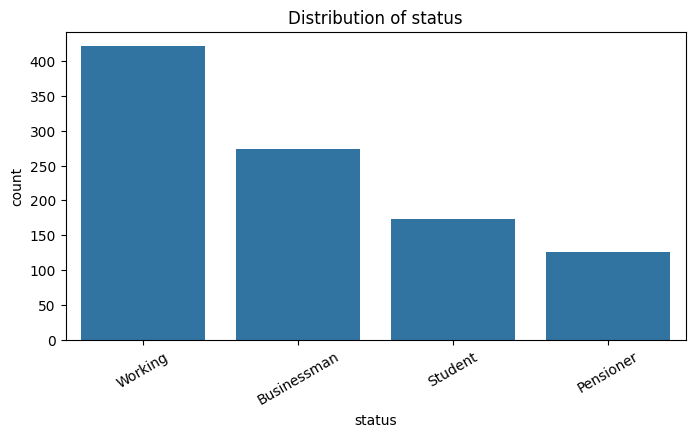

status
Working        421
Businessman    274
Student        173
Pensioner      126
NaN              6
Name: count, dtype: int64

In [59]:
plt.figure(figsize=(8, 4))
sns.countplot(data=df_eda, x="status", order=df_eda["status"].value_counts().index)
plt.title("Distribution of status")
plt.xticks(rotation=30)
plt.show()

display(df_eda["status"].value_counts(dropna=False))

In [60]:
def build_quality_report(dataframe):
    """
    Формирует сводный отчет по качеству данных для переданного DataFrame.

    Функция рассчитывает основные метрики качества по каждому признаку:
    - тип данных
    - количество непустых значений
    - количество пропусков
    - процент пропусков
    - количество уникальных значений
    - примеры первых уникальных непустых значений

    Параметры
    ----------
    dataframe : pd.DataFrame
        Исходный датафрейм для анализа качества данных

    Возвращает
    ----------
    pd.DataFrame
        Отсортированный отчет по качеству данных
        в порядке убывания доли пропусков
    """
    report = pd.DataFrame({
        "dtype": dataframe.dtypes.astype(str),
        "non_null_count": dataframe.notna().sum(),
        "missing_count": dataframe.isna().sum(),
        "missing_percent": (dataframe.isna().mean() * 100).round(2),
        "n_unique": dataframe.nunique(dropna=True)
    })

    report["sample_values"] = [
        list(dataframe[col].dropna().astype(str).unique()[:5])
        for col in dataframe.columns
    ]

    return report.sort_values(by="missing_percent", ascending=False)


quality_before = build_quality_report(df_eda)
display(quality_before)

,dtype,non_null_count,missing_count,missing_percent,n_unique,sample_values
income,float64,823,177,17.7000,392,"[4000.0, 0.0, 1000.0, 2000.0, 5000.0]"
age,float64,968,32,3.2000,76,"[18.0, 0.0, 20.0, 22.0, 73.0]"
status,object,994,6,0.6000,4,"[Student, Businessman, Pensioner, Working]"
timestamp,datetime64[ns],1000,0,0.0000,29,"[2026-03-02, 2026-03-25, 2026-03-29, 2026-03-0..."


,timestamp,day,weekday
0,2026-03-02,2,Monday
1,2026-03-25,25,Wednesday
2,2026-03-29,29,Sunday
3,2026-03-05,5,Thursday
4,2026-03-06,6,Friday


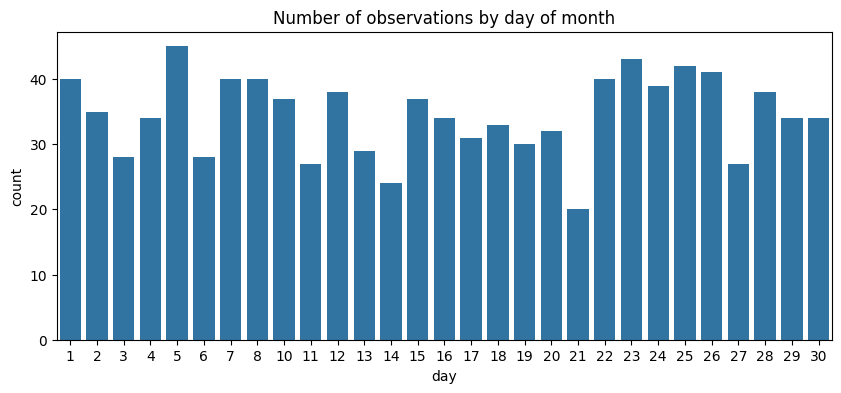

In [61]:
df_eda["day"] = df_eda["timestamp"].dt.day
df_eda["weekday"] = df_eda["timestamp"].dt.day_name()

display(df_eda[["timestamp", "day", "weekday"]].head())

plt.figure(figsize=(10, 4))
sns.countplot(data=df_eda, x="day")
plt.title("Number of observations by day of month")
plt.show()

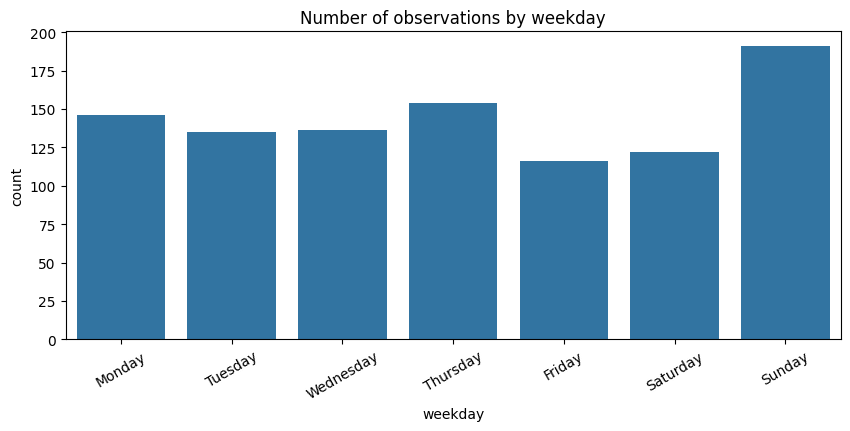

In [62]:
plt.figure(figsize=(10, 4))
sns.countplot(data=df_eda, x="weekday",
              order=["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"])
plt.title("Number of observations by weekday")
plt.xticks(rotation=30)
plt.show()

Распределение наблюдений по дням месяца является относительно равномерным.

Анализ по дням недели также не выявил критических смещений, хотя наблюдается несколько большее количество записей в воскресенье.


## Временная динамика признаков

Для более детального анализа временной структуры данных используется агрегация по дате


In [63]:
df_time = df.copy()
df_time["timestamp"] = pd.to_datetime(df_time["timestamp"])
df_time = df_time.set_index("timestamp")

daily_stats = df_time.resample("D").agg({
    "income": ["count", "mean"],
    "age": "mean"
})

daily_stats.columns = ["income_count", "income_mean", "age_mean"]

display(daily_stats.head())

,income_count,income_mean,age_mean
timestamp,,,
2026-03-01,33,"226,401.1818",49.3684
2026-03-02,26,"137,000.0000",44.4571
2026-03-03,24,"71,753.9583",42.0769
2026-03-04,27,"128,481.4815",43.6364
2026-03-05,35,"140,579.4286",41.5333


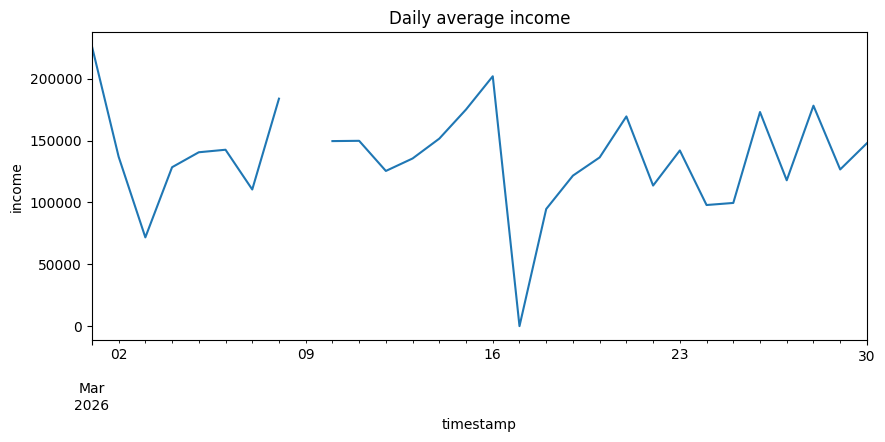

In [64]:
plt.figure(figsize=(10, 4))
daily_stats["income_mean"].plot()
plt.title("Daily average income")
plt.ylabel("income")
plt.show()

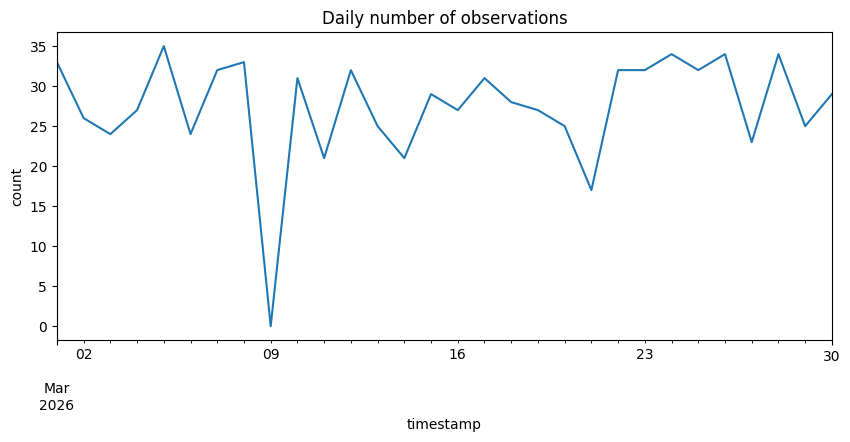

In [65]:
plt.figure(figsize=(10, 4))
daily_stats["income_count"].plot()
plt.title("Daily number of observations")
plt.ylabel("count")
plt.show()

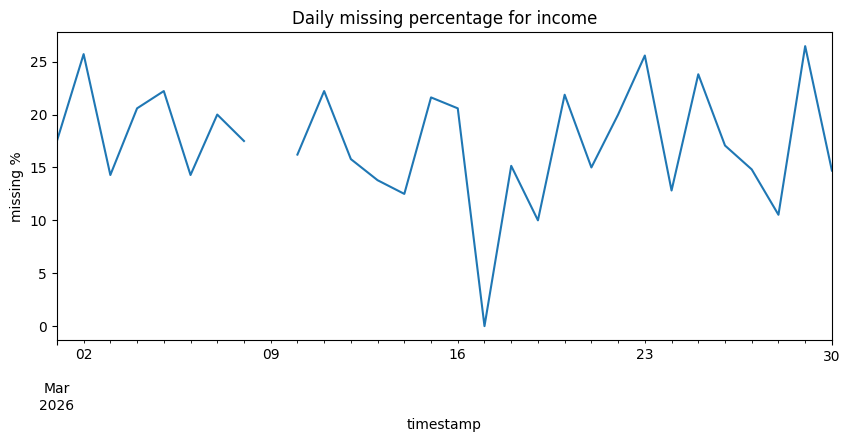

In [66]:
missing_by_day = (
    df.assign(timestamp=pd.to_datetime(df["timestamp"]))
      .set_index("timestamp")
      .groupby(pd.Grouper(freq="D"))["income"]
      .apply(lambda x: x.isna().mean() * 100)
)

plt.figure(figsize=(10, 4))
missing_by_day.plot()
plt.title("Daily missing percentage for income")
plt.ylabel("missing %")
plt.show()

## Вывод по временной динамике данных


### Количество наблюдений
В течение месяца число наблюдений в целом остается стабильным и колеблется в диапазоне **20–35 записей в день**.

Отдельно выделяется **09.03.2026**, где количество наблюдений равно нулю.

### Средний доход
Среднее значение дохода в большинстве дней находится на сопоставимом уровне и не демонстрирует выраженного временного тренда.

При этом **17.03.2026** наблюдается резкий провал среднего дохода почти до нуля.

### Пропуски
В день аномального снижения среднего дохода доля пропусков равна **0%**


In [67]:
day_17 = df_eda[df_eda["timestamp"] == "2026-03-17"]

display(day_17["status"].value_counts())
display(day_17[["income", "age"]].describe())

status
Working        12
Businessman     9
Student         6
Pensioner       4
Name: count, dtype: int64

,income,age
count,31.0000,29.0000
mean,0.0000,43.0000
std,0.0000,21.1018
min,0.0000,0.0000
25%,0.0000,26.0000
50%,0.0000,43.0000
75%,0.0000,59.0000
max,0.0000,80.0000


age                                
            count    mean  median     min     max
status                                           
Businessman   255 49.6157 49.0000 16.0000 80.0000
Pensioner     113 72.4956 70.0000 60.0000 99.0000
Student       173 17.3584 20.0000  0.0000 26.0000
Working       421 42.9145 43.0000 20.0000 60.0000

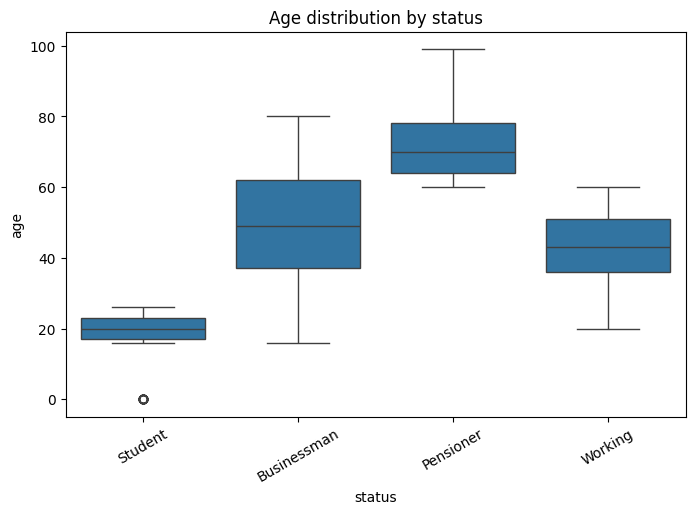

In [68]:
age_summary = (
    df_eda.groupby("status")
    .agg({
        "age": ["count", "mean", "median", "min", "max"]
    })
)

display(age_summary)

plt.figure(figsize=(8, 5))
sns.boxplot(data=df_eda, x="status", y="age")
plt.xticks(rotation=30)
plt.title("Age distribution by status")
plt.show()

Категориальный признак `status` согласуется с возрастной структурой выборки.

income                                                      \
             count         mean       median          min          max   
status                                                                   
Businessman    229 278,025.1921 198,000.0000 -13,150.0000 992,000.0000   
Pensioner       99  14,213.9798  15,000.0000 -13,035.0000  30,000.0000   
Student        146   1,811.1301   2,000.0000 -13,745.0000  79,000.0000   
Working        348 134,241.3793 128,500.0000 -12,331.0000 298,000.0000   

                age          
               mean  median  
status                       
Businessman 49.6157 49.0000  
Pensioner   72.4956 70.0000  
Student     17.3584 20.0000  
Working     42.9145 43.0000

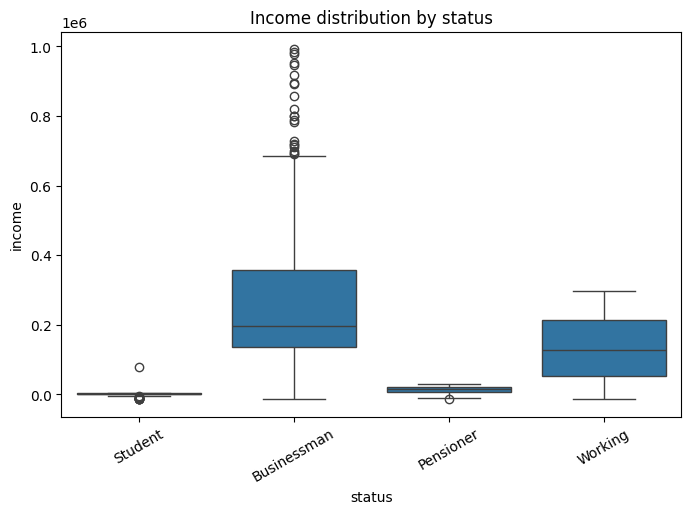

In [69]:
status_summary = (
    df_eda.groupby("status")
    .agg({
        "income": ["count", "mean", "median", "min", "max"],
        "age": ["mean", "median"]
    })
)

display(status_summary)

plt.figure(figsize=(8, 5))
sns.boxplot(data=df_eda, x="status", y="income")
plt.xticks(rotation=30)
plt.title("Income distribution by status")
plt.show()

Распределение дохода существенно различается между категориями клиентов.
- `Businessman` демонстрирует наибольший медианный доход и самый широкий разброс значений
- `Working` также характеризуется высоким уровнем дохода, однако распределение более стабильное
- `Student` имеет минимальный уровень дохода
- `Pensioner` характеризуется умеренным и относительно компактным распределением

Полученные результаты позволяют сделать вывод, что признак `status` обладает значительно большей объясняющей способностью по отношению к доходу, чем возраст клиента.

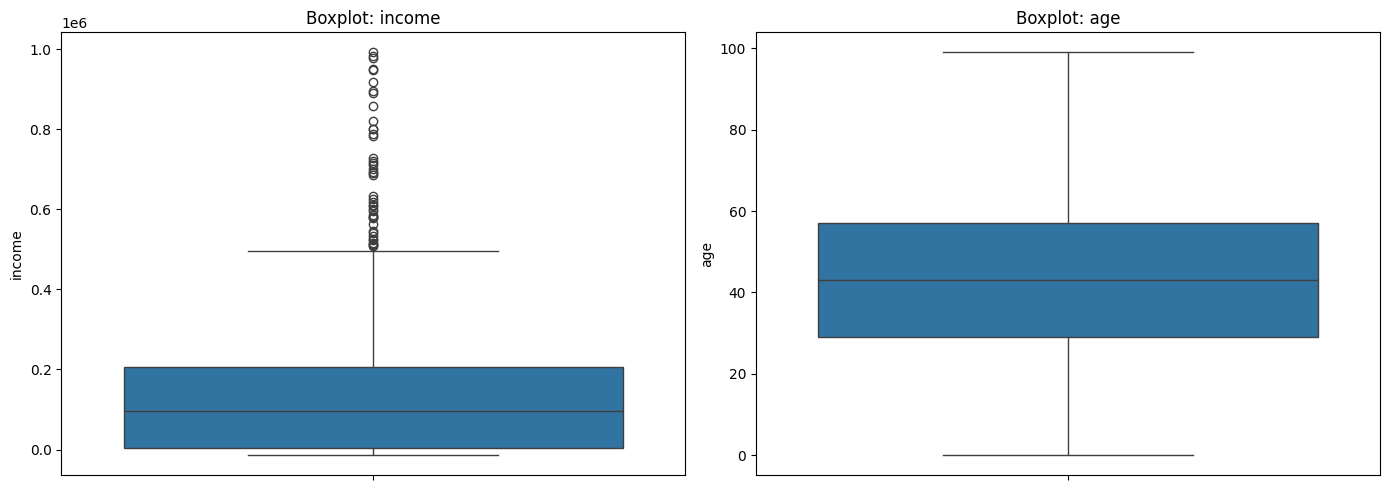

In [70]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(y=df_eda["income"], ax=axes[0])
axes[0].set_title("Boxplot: income")

sns.boxplot(y=df_eda["age"], ax=axes[1])
axes[1].set_title("Boxplot: age")

plt.tight_layout()
plt.show()

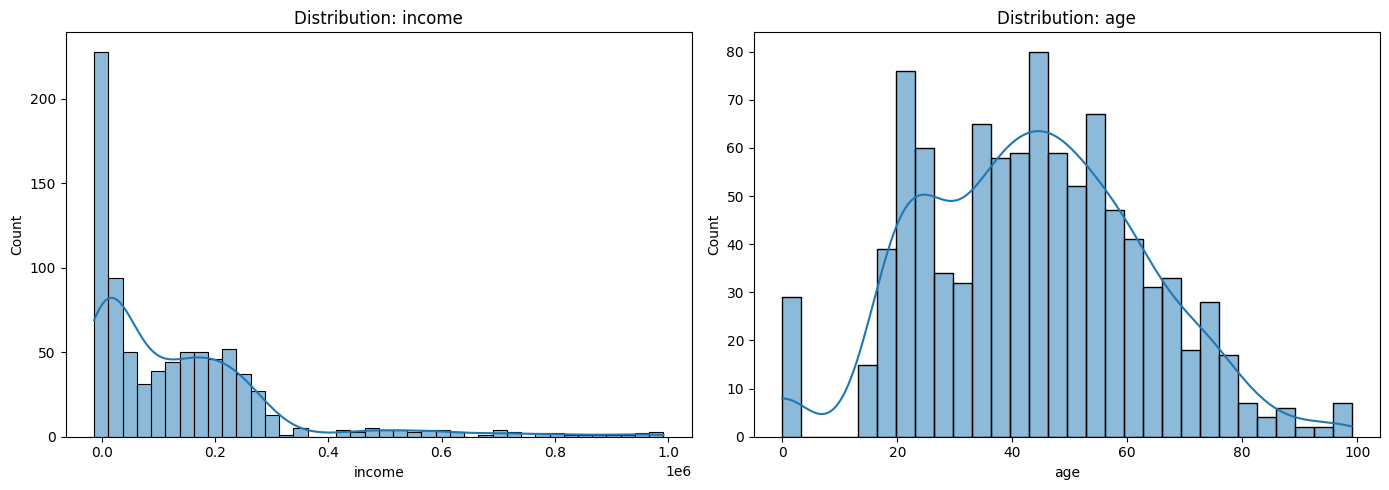

In [71]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df_eda["income"], bins=40, kde=True, ax=axes[0])
axes[0].set_title("Distribution: income")

sns.histplot(df_eda["age"], bins=30, kde=True, ax=axes[1])
axes[1].set_title("Distribution: age")

plt.tight_layout()
plt.show()

,income,age
income,1.0000,0.2072
age,0.2072,1.0000


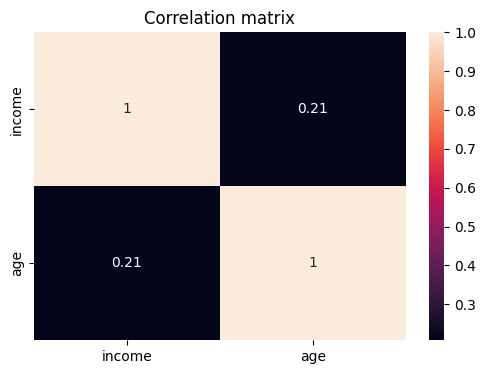

In [72]:
corr_matrix = df_eda[["income", "age"]].corr()

display(corr_matrix)

plt.figure(figsize=(6, 4))
sns.heatmap(corr_matrix, annot=True)
plt.title("Correlation matrix")
plt.show()

Слабая корреляция указывает на ограниченную линейную объясняющую способность признака age относительно income.

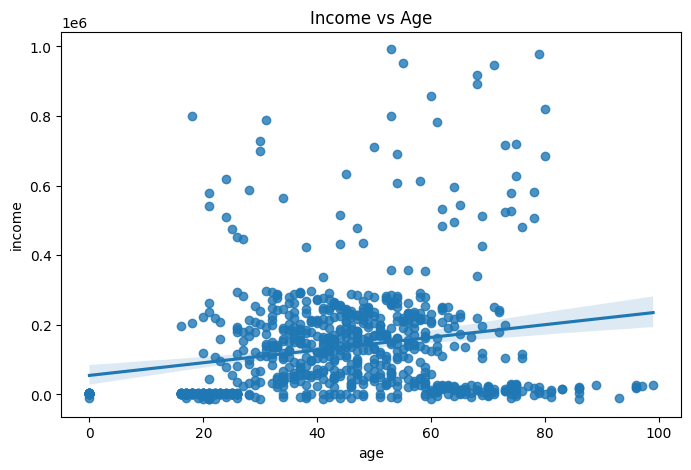

In [73]:
plt.figure(figsize=(8, 5))
sns.regplot(data=df_eda, x="age", y="income")
plt.title("Income vs Age")
plt.show()

слабый восходящий тренд

In [74]:
def detect_outliers_iqr(series):
    """
    Выполняет поиск выбросов методом межквартильного размаха (IQR).
    
    """
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    outliers = series[(series < lower) | (series > upper)]

    return {
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "lower_bound": lower,
        "upper_bound": upper,
        "outliers_count": outliers.shape[0]
    }


income_outliers = detect_outliers_iqr(df_eda["income"].dropna())
age_outliers = detect_outliers_iqr(df_eda["age"].dropna())

print("Income outliers:", income_outliers)
print("Age outliers:", age_outliers)

Income outliers: {'Q1': 5000.0, 'Q3': 205500.0, 'IQR': 200500.0, 'lower_bound': -295750.0, 'upper_bound': 506250.0, 'outliers_count': 43}
Age outliers: {'Q1': 29.0, 'Q3': 57.0, 'IQR': 28.0, 'lower_bound': -13.0, 'upper_bound': 99.0, 'outliers_count': 0}


## Анализ распределений и выбросов

По признаку `income` наблюдается выраженная правосторонняя асимметрия распределения с длинным правым хвостом.

С помощью метода межквартильного размаха (IQR) было выявлено **43 выброса**, превышающих верхнюю границу `506 250`.

Для признака `age` статистические выбросы отсутствуют, однако присутствуют логически некорректные значения (`age = 0`), которые будут интерпретированы как ошибки заполнения.



# Обоснование методов очистки данных


## Пропуски

### Категориальные признаки
Для признака `status` используется импутация модой как наиболее частой категорией.


### Числовой признак `age`
Для возраста используется **медианная импутация**, поскольку распределение признака близко к симметричному, а медиана устойчива к выбросам.


### Числовой признак `income`
Для признака `income` применяется **стохастическая регрессионная импутация внутри групп `status`**.

Такой подход выбран по следующим причинам:

- доход существенно зависит от категории клиента
- простая глобальная медиана искажает структуру данных
- стохастическая импутация сохраняет естественную вариативность внутри группы
- **снижается риск появления искусственных горизонтальных линий на графиках**

Пропущенные значения заполняются случайными значениями, сгенерированными из нормального распределения вокруг среднего значения соответствующей группы.


## Выбросы

Для признака `income` используется **мягкий winsorizing с jitter** внутри каждой категории `status`.

Выбросы определяются методом межквартильного размаха (IQR)

Значения за пределами допустимого диапазона не обрезаются жестко до одной точки, а заменяются на пограничные значения с добавлением небольшого случайного шума.


In [ ]:
def clean_dataset(dataframe):
    """
    Выполняет полную очистку датасета с учетом
    временных аномалий и групповой структуры признака status.

    Этапы очистки включают:
    - удаление технического индексного столбца
    - приведение timestamp к типу datetime
    - выявление и маркировку аномального batch
    - обработку логически некорректных значений
    - импутацию пропусков
    - мягкую обработку выбросов по income внутри групп status.

    """
    df_clean = dataframe.copy()

    if "Unnamed: 0" in df_clean.columns:
        df_clean = df_clean.drop(columns=["Unnamed: 0"])

    df_clean["timestamp"] = pd.to_datetime(df_clean["timestamp"])

    anomalous_date = pd.Timestamp("2026-03-17")
    df_clean["is_anomalous_batch"] = (
        df_clean["timestamp"] == anomalous_date
    ).astype(int)

    df_clean.loc[df_clean["age"] == 0, "age"] = np.nan
    df_clean.loc[df_clean["income"] < 0, "income"] = np.nan
    df_clean.loc[
        (df_clean["is_anomalous_batch"] == 1) & (df_clean["income"] == 0),
        "income"
    ] = np.nan

    df_clean["status"] = df_clean["status"].fillna(df_clean["status"].mode()[0])
    df_clean["age"] = df_clean["age"].fillna(df_clean["age"].median())

    def stochastic_impute(group):
        """
    Выполняет стохастическую импутацию пропусков
    в признаке income внутри одной группы status.

    Пропущенные значения заполняются случайными
    значениями из нормального распределения,
    параметры которого оцениваются по группе.

        """    
        mean_val = group["income"].mean()
        std_val = group["income"].std()

        missing_mask = group["income"].isna()

        group.loc[missing_mask, "income"] = np.random.normal(
            mean_val,
            std_val * 0.1,
            missing_mask.sum()
        )
        return group

    def soft_winsorize(group):
        """
    Выполняет мягкую обработку выбросов

    Выбросы определяются методом IQR
    Значения за пределами допустимого диапазона
    заменяются на пограничные значения с
    небольшим случайным шумом.
    
        """    
        q1 = group["income"].quantile(0.25)
        q3 = group["income"].quantile(0.75)
        iqr = q3 - q1

        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr

        noise_std = iqr * 0.03

        high_mask = group["income"] > upper
        low_mask = group["income"] < lower

        group.loc[high_mask, "income"] = (
            upper + np.random.normal(0, noise_std, high_mask.sum())
        )

        group.loc[low_mask, "income"] = (
            lower + np.random.normal(0, noise_std, low_mask.sum())
        )

        return group

    df_clean = (
        df_clean.groupby("status", group_keys=False)
        .apply(stochastic_impute)
        .groupby("status", group_keys=False)
        .apply(soft_winsorize)
    )

    return df_clean

df_clean = clean_dataset(df)
display(df_clean.head())

C:\Users\denis\AppData\Local\Temp\ipykernel_22080\332929356.py:87: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(stochastic_impute)
C:\Users\denis\AppData\Local\Temp\ipykernel_22080\332929356.py:89: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(soft_winsorize)


,Unnamed: 0,status,income,age,timestamp,is_anomalous_batch
0,0,Student,"4,000.0000",18.0000,2026-03-02,0
1,1,Student,"4,000.0000",18.0000,2026-03-25,0
2,2,Student,0.0000,44.0000,2026-03-29,0
3,3,Student,"1,000.0000",20.0000,2026-03-05,0
4,4,Student,"2,000.0000",22.0000,2026-03-06,0


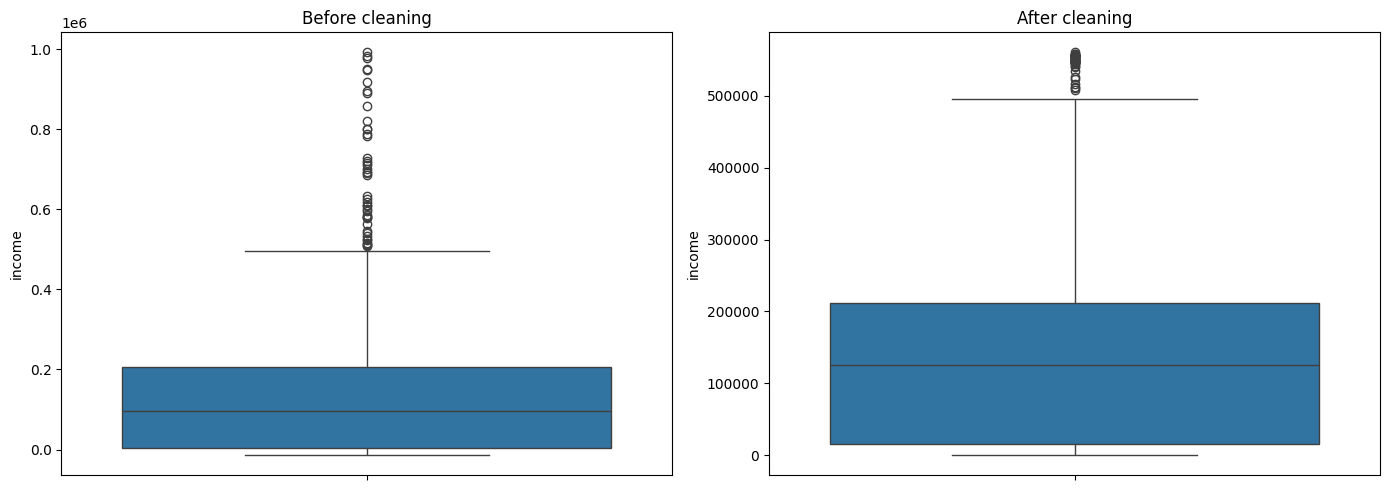

In [76]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(y=df["income"], ax=axes[0])
axes[0].set_title("Before cleaning")

sns.boxplot(y=df_clean["income"], ax=axes[1])
axes[1].set_title("After cleaning")

plt.tight_layout()
plt.show()

Верхние значения трогали очень слабо, поэтому сохранились высокие доходы и выбросы.
С помощью этого получилась большая етсественная вариабельность.

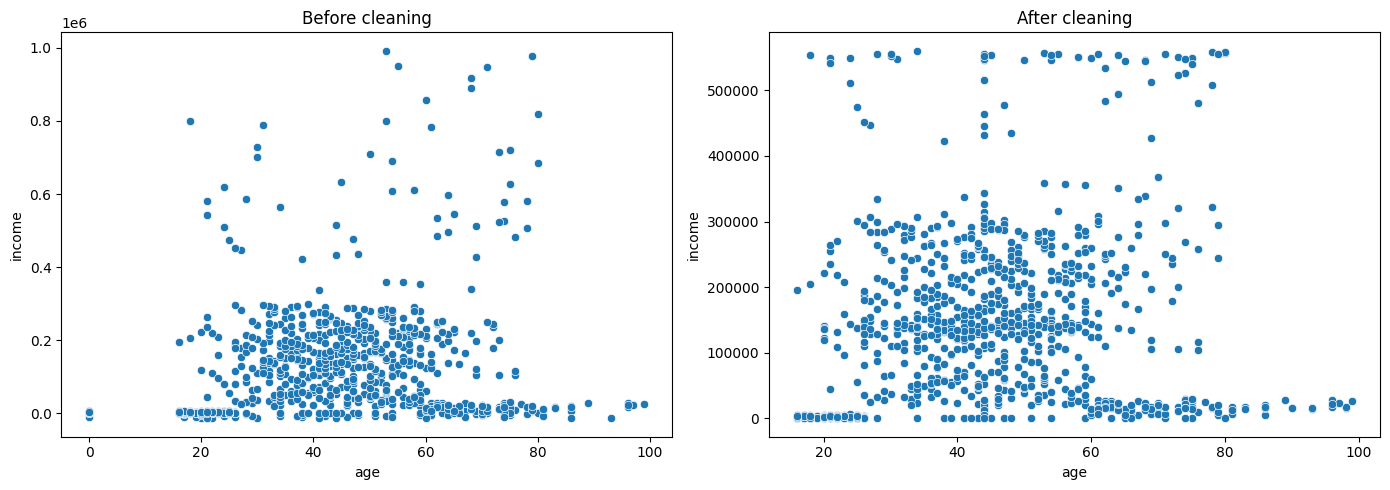

In [77]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(data=df, x="age", y="income", ax=axes[0])
axes[0].set_title("Before cleaning")

sns.scatterplot(data=df_clean, x="age", y="income", ax=axes[1])
axes[1].set_title("After cleaning")

plt.tight_layout()
plt.show()

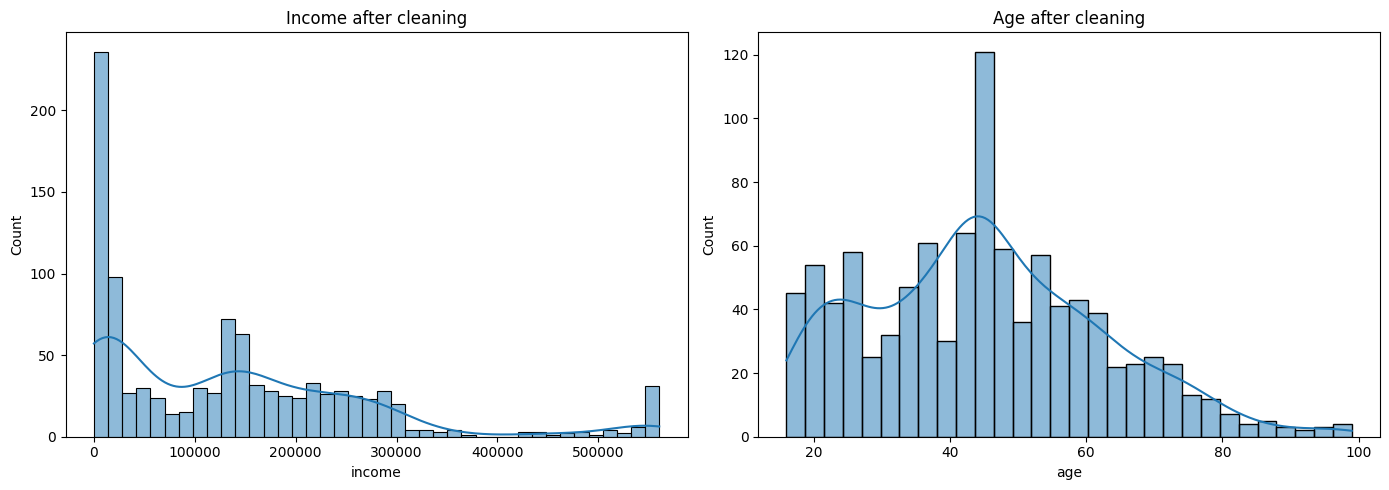

In [78]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df_clean["income"], bins=40, kde=True, ax=axes[0])
axes[0].set_title("Income after cleaning")

sns.histplot(df_clean["age"], bins=30, kde=True, ax=axes[1])
axes[1].set_title("Age after cleaning")

plt.tight_layout()
plt.show()

cleaning не сломал распределение

In [79]:
quality_after = build_quality_report(df_clean)
display(quality_after)

print("Пропуски после очистки:")
display(df_clean.isna().sum())

print("Минимальный возраст:", df_clean["age"].min())
print("Минимальный доход:", df_clean["income"].min())
print("Максимальный доход:", df_clean["income"].max())

,dtype,non_null_count,missing_count,missing_percent,n_unique,sample_values
Unnamed: 0,int64,1000,0,0.0000,1000,"[0, 1, 2, 3, 4]"
status,object,1000,0,0.0000,4,"[Student, Businessman, Pensioner, Working]"
income,float64,1000,0,0.0000,571,"[4000.0, 0.0, 1000.0, 2000.0, 320299.3105588849]"
age,float64,1000,0,0.0000,75,"[18.0, 44.0, 20.0, 22.0, 73.0]"
timestamp,object,1000,0,0.0000,29,"[2026-03-02, 2026-03-25, 2026-03-29, 2026-03-0..."
is_anomalous_batch,int32,1000,0,0.0000,1,[0]


Пропуски после очистки:


Unnamed: 0            0
status                0
income                0
age                   0
timestamp             0
is_anomalous_batch    0
dtype: int64

Минимальный возраст: 16.0
Минимальный доход: 0.0
Максимальный доход: 560488.4420076163


In [80]:
comparison = pd.DataFrame({
    "metric": [
        "rows",
        "columns",
        "missing_total",
        "income_min",
        "income_median",
        "income_max",
        "age_min",
        "age_median",
        "age_max"
    ],
    "before": [
        df_eda.shape[0],
        df_eda.shape[1],
        df_eda.isna().sum().sum(),
        df_eda["income"].min(),
        df_eda["income"].median(),
        df_eda["income"].max(),
        df_eda["age"].min(),
        df_eda["age"].median(),
        df_eda["age"].max()
    ],
    "after": [
        df_clean.shape[0],
        df_clean.shape[1],
        df_clean.isna().sum().sum(),
        df_clean["income"].min(),
        df_clean["income"].median(),
        df_clean["income"].max(),
        df_clean["age"].min(),
        df_clean["age"].median(),
        df_clean["age"].max()
    ]
})

display(comparison)

,metric,before,after
0,rows,"1,000.0000","1,000.0000"
1,columns,6.0000,6.0000
2,missing_total,215.0000,0.0000
3,income_min,"-13,745.0000",0.0000
4,income_median,"96,000.0000","126,000.0000"
5,income_max,"992,000.0000","560,488.4420"
6,age_min,0.0000,16.0000
7,age_median,43.0000,44.0000
8,age_max,99.0000,99.0000


# Итоговый вывод

В ходе разведочного анализа были выявлены:
- пропуски в числовых и категориальных признаках
- логически некорректные значения
- экстремальные выбросы по доходу

После очистки данных:
- все пропуски устранены
- аномальные значения исправлены
- влияние выбросов снижено
- получен полностью пригодный для дальнейшего анализа и моделирования датафрейм

Использование групповой стохастической импутации и мягкого winsorizing позволило сохранить естественную структуру данных и избежать появления искусственных артефактов на графиках.